### Task VII: Equivariant quantum neural networks
In this task you are supposed to get started with equivariant quantum neural networks by implementing a Z_2 × Z_2 equivariant quantum neural network. Z_2 is a symmetry group an as an example we will generate a simple classical dataset which is respects the Z_2 x Z_2 symmetry.

This example is explained in the paper https://arxiv.org/abs/2205.06217 and additional background can be found in https://arxiv.org/abs/2210.08566.

Generate a classification dataset with two classes and two features x_1 and x_2 which respects the Z_2 x Z_2 symmetry (this corresponds to mirroring along y=x). An example can be found in the first reference paper.
Train a QNN to solve the classification problem
Train an Z_2 x Z_2 equivariant QNN to solve the classification problem and compare the results.


In [2]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 1. Generate Z2 x Z2 Symmetric Dataset (Mirroring along y=x)
def generate_data(n_samples=200):
    X = np.random.uniform(-1, 1, (n_samples, 2))
    # Label is 1 if features have the same sign (Quadrant 1 & 3), else 0
    # This is invariant under swapping x1 and x2
    y = np.array([1 if x[0] * x[1] > 0 else 0 for x in X], requires_grad=False)
    return X, y

X, y = generate_data()
dev = qml.device("default.qubit", wires=2)

In [4]:
# 2. Define the EQNN (Equivariant) and QNN (Standard)
# For Z2 symmetry, the circuit must commute with the SWAP gate.
# Symmetric layers use identical rotations on both qubits and symmetric entanglers (CZ/IsingXX).

def equivariant_layer(params):
    # Same rotation on both qubits respects permutation symmetry
    qml.RY(params[0], wires=0)
    qml.RY(params[0], wires=1)
    # CZ gate is symmetric (commutes with SWAP)
    qml.CZ(wires=[0, 1])

def standard_layer(params):
    # Independent rotations break symmetry
    qml.RY(params[0], wires=0)
    qml.RY(params[1], wires=1)
    qml.CNOT(wires=[0, 1])

In [5]:
@qml.qnode(dev)
def circuit(weights, x, equivariant=True):
    # Encoding: Map features to rotation angles
    qml.RY(x[0], wires=0)
    qml.RY(x[1], wires=1)

    # Trainable Layers
    for w in weights:
        if equivariant:
            equivariant_layer(w)
        else:
            standard_layer(w)

    # Symmetric Measurement: Z0 + Z1 is invariant under swapping 0 and 1
    return qml.expval(qml.PauliZ(0) + qml.PauliZ(1))

In [6]:
# 3. Training Logic
def train_model(equivariant=True):
    # Weights shape: (layers, params_per_layer)
    num_layers = 3
    param_shape = (num_layers, 1) if equivariant else (num_layers, 2)
    weights = np.random.random(param_shape, requires_grad=True)

    opt = qml.AdamOptimizer(stepsize=0.1)

    def cost(w):
        # MSE loss between circuit output and labels (scaled to PauliZ range)
        preds = np.array([circuit(w, x, equivariant=equivariant) for x in X])
        target = 2 * y - 1  # Map {0, 1} to {-1, 1}
        return np.mean((preds - target)**2)

    for i in range(50):
        weights = opt.step(cost, weights)
        if i % 10 == 0:
            print(f"Step {i}, Cost: {cost(weights):.4f}")
    return weights

Training Equivariant QNN...
Step 0, Cost: 1.5891
Step 10, Cost: 1.0816
Step 20, Cost: 0.8274
Step 30, Cost: 0.7477
Step 40, Cost: 0.7386

Training Standard QNN...
Step 0, Cost: 1.4617
Step 10, Cost: 0.8242
Step 20, Cost: 0.7594
Step 30, Cost: 0.6977
Step 40, Cost: 0.6598


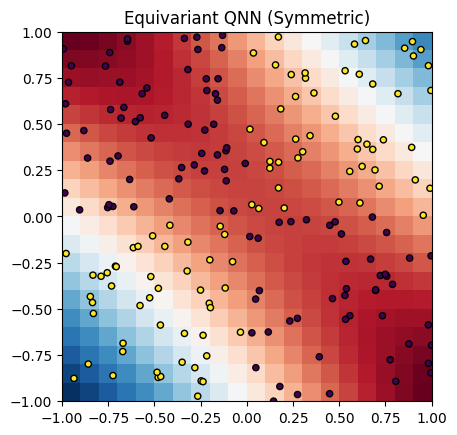

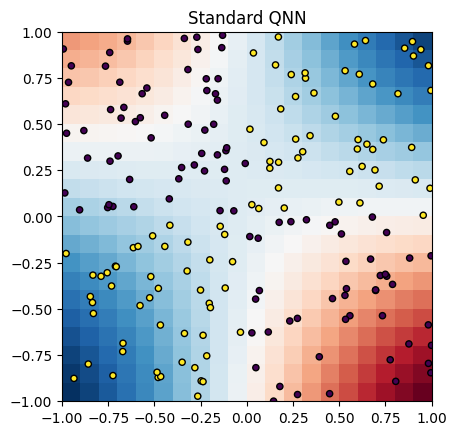

In [7]:
print("Training Equivariant QNN...")
weights_eq = train_model(equivariant=True)

print("\nTraining Standard QNN...")
weights_std = train_model(equivariant=False)

# 4. Compare Results (Visualizing Decision Boundary)
def plot_decision_boundary(weights, equivariant, title):
    grid = np.linspace(-1, 1, 20)
    res = np.zeros((20, 20))
    for i, x1 in enumerate(grid):
        for j, x2 in enumerate(grid):
            res[i, j] = circuit(weights, [x1, x2], equivariant=equivariant)

    plt.imshow(res, extent=[-1, 1, -1, 1], origin='lower', cmap='RdBu')
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', s=20)
    plt.title(title)
    plt.show()

plot_decision_boundary(weights_eq, True, "Equivariant QNN (Symmetric)")
plot_decision_boundary(weights_std, False, "Standard QNN")

The Equivariant QNN is more "red" (and blue) in specific symmetric zones because it has correctly identified the global $Z_2 \times Z_2$ rule ($x_1 \cdot x_2 > 0$), resulting in a confident, mirrored checkerboard. The Standard QNN appears to have "less" red or more faded colors because it is struggling to find a consistent rule; without the symmetry constraint, it treats every data point as a local exception, leading to a weaker, asymmetric decision boundary that fails to generalize across the entire plane. Essentially, the Equivariant model "knows" the pattern should repeat across the diagonal $y=x$, while the Standard model is still guessing.